In [1]:
import xarray as xr
import fsspec
#import intake
from pathlib import Path

import numpy as np
import pandas as pd
import scipy
import scipy.stats as stats
from scipy.stats import ttest_ind, mstats

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean

import dask
import pickle

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean

from scipy.stats import genextreme as gev, kstest


# Set up figure

fs = fsspec.filesystem("")

In [2]:
#path = '../../create_analysis_dataset/data/'
path = '../data/'
var = 'UTCI'  # Can be changed to 'UTCI' or other heat indices
baseline_time = slice('1970', '1999')
recent_time = slice('1993', '2022')

In [3]:
da = xr.open_zarr(f'{path}/heat_analysis_set.zarr')[var] - 273.15
da = da.sel(latitude = slice(20,-60))

baseline = da.sel(time = baseline_time).chunk({"time": -1})
recent = da.sel(time = recent_time).chunk({"time": -1})

In [4]:
da = da.chunk({'time': -1}).resample(time='1YE').max(dim='time')

baseline = da.sel(time = baseline_time).chunk({"time": -1})
recent = da.sel(time = recent_time).chunk({"time": -1})

In [5]:
def fit_gev(x):
    x = x[~np.isnan(x)]
    if len(x) < 10:
        return np.full(4, np.nan)
    try:
        shape, loc, scale = gev.fit(x)
        D, _ = kstest(x, gev.cdf, args=(shape, loc, scale))
        return np.array([shape, loc, scale, D], dtype=np.float32)
    except:
        return np.full(4, np.nan)

In [6]:
def return_gev(da):
    """
    Applies GEV fitting across time and extracts shape, loc, scale, and KS-statistic
    """
    params = xr.apply_ufunc(
        fit_gev,
        da.chunk({'time': -1}),  # ensure single chunk over 'time'
        input_core_dims=[["time"]],
        output_core_dims=[["gev_param"]],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[float],
        dask_gufunc_kwargs={"output_sizes": {"gev_param": 4}},
    )

    params.name = "gev_params"
    params.coords["gev_param"] = ["gev_shape", "gev_loc", "gev_scale", "ks_stat"]

    # Split into individual variables
    split = {
        name: params.isel(gev_param=i).drop_vars("gev_param").rename(name)
        for i, name in enumerate(["gev_shape", "gev_loc", "gev_scale", "ks_stat"])
    }

    return xr.Dataset(split)

baseline_gev = return_gev(baseline).compute()
recent_gev = return_gev(recent).compute()

/Users/peter/.local/share/mamba/envs/som_pytorch_env/lib/python3.12/site-packages/dask/array/reductions.py:324: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(x_chunk, axis=axis, keepdims=keepdims)
/Users/peter/.local/share/mamba/envs/som_pytorch_env/lib/python3.12/site-packages/dask/array/reductions.py:324: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(x_chunk, axis=axis, keepdims=keepdims)
/Users/peter/.local/share/mamba/envs/som_pytorch_env/lib/python3.12/site-packages/dask/array/reductions.py:324: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(x_chunk, axis=axis, keepdims=keepdims)


In [7]:
diff_gev = recent_gev - baseline_gev

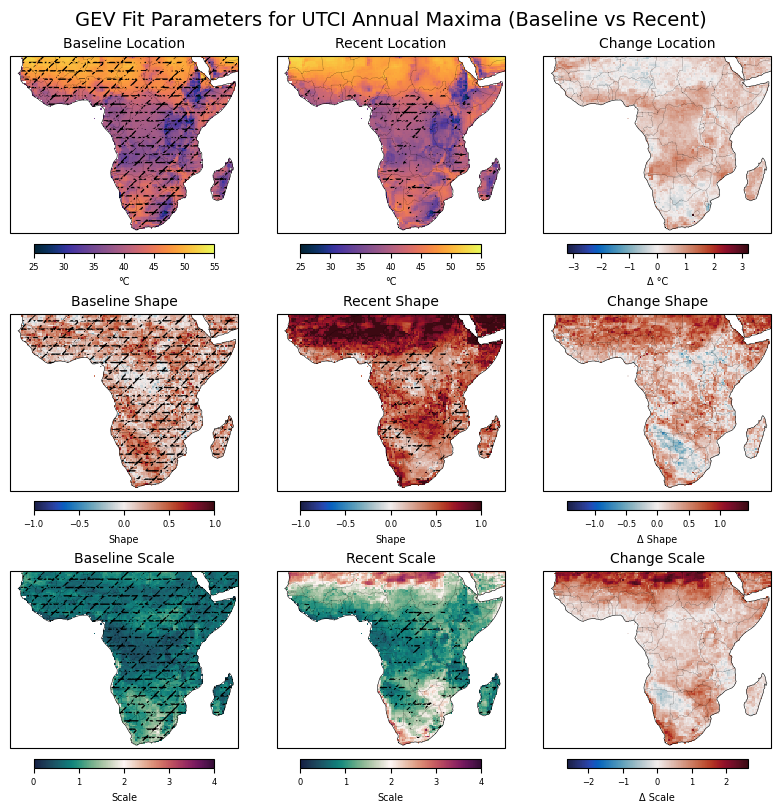

In [9]:
# Set up grid and parameters
params = ['gev_loc', 'gev_shape', 'gev_scale']
param_names = ['Location', 'Shape', 'Scale']
cmap = 'RdBu_r'

# Custom plotting configs per parameter
plot_config = {
    'gev_shape': {'vmin': -1, 'vmax': 1, 'cmap': cmocean.cm.balance, 'units': 'Shape'},
    'gev_loc': {'vmin': 25, 'vmax': 55, 'cmap': cmocean.cm.thermal, 'units': '°C'},
    'gev_scale': {'vmin': 0, 'vmax': 4, 'cmap': cmocean.cm.curl, 'units': 'Scale'},
}

ks_thresh = 0.1
baseline_goodfit = (baseline_gev['ks_stat'] <= ks_thresh)
recent_goodfit = (recent_gev['ks_stat'] <= ks_thresh)

fig, axes = plt.subplots(
    nrows=3, ncols=3, figsize=(8, 8),
    subplot_kw={'projection': ccrs.PlateCarree()},
    constrained_layout=True
)

axes = axes.flatten()

# Plotting loop
for i, param in enumerate(params):
    for j, dataset in enumerate([baseline_gev, recent_gev, diff_gev]):
        idx = i * 3 + j
        ax = axes[idx]
        title_prefix = ["Baseline", "Recent", "Change"][j]
        config = plot_config[param]

        # Use balance colormap for difference panels, otherwise use parameter-specific colormap
        plot_cmap = cmocean.cm.balance if j == 2 else config['cmap']
        
        # Don't set vmin/vmax for difference panels, but use them for baseline/recent
        plot_kwargs = {
            'ax': ax,
            'transform': ccrs.PlateCarree(),
            'cmap': plot_cmap,
            'add_colorbar': False
        }
        
        if j != 2:  # Not a difference panel
            plot_kwargs.update({
                'vmin': config['vmin'],
                'vmax': config['vmax']
            })
        
        im = dataset[param].plot(**plot_kwargs)

        # Stipple areas with poor KS fit
        if j == 0:  # Baseline
            mask = baseline_goodfit
        elif j == 1:  # Recent
            mask = recent_goodfit
        else:
            mask = (baseline_goodfit | recent_goodfit)  # For change: mark either
        if j != 2:
            mask.plot.contourf(
                ax=ax,
                transform=ccrs.PlateCarree(),
                levels=[-0.5, 0.5, 1.5],
                hatches=[None, "--//"],
                colors="none",
                add_colorbar=False,
                alpha=0
            )

        # Add coastlines/borders/formatting
        ax.set_title(f'{title_prefix} {param_names[i]}', fontsize=10)
        ax.add_feature(cfeature.COASTLINE, linewidth=0.4)
        ax.add_feature(cfeature.BORDERS, linewidth=0.3, linestyle=":")

        # Add colorbar below each plot
        cbar = fig.colorbar(im, ax=ax, orientation='horizontal', shrink=0.7, pad=0.05)
        cbar.ax.tick_params(labelsize=6)
        if j == 2:  # Difference panel
            cbar.set_label(f'Δ {config["units"]}', fontsize=7)
        else:
            cbar.set_label(config["units"], fontsize=7)

fig.suptitle('GEV Fit Parameters for UTCI Annual Maxima (Baseline vs Recent)', fontsize=14)

plt.savefig('plots/01_gev_trend.png', dpi=300, bbox_inches='tight')

plt.show()


## Figure Caption

**Figure 1: Generalized Extreme Value (GEV) parameter changes in UTCI annual maxima between baseline (1970-1999) and recent (1993-2022) periods.**

This figure shows spatial patterns of GEV distribution parameters fitted to annual maximum Universal Thermal Climate Index (UTCI) values across Africa and surrounding regions. The analysis compares two overlapping periods: a baseline period (1970-1999, left column) and a recent period (1993-2022, middle column), with their differences shown in the right column. 

**Top row (Location parameter):** Shows the location parameter (μ) in °C, representing the mode of the GEV distribution and indicating the most likely value of annual maximum UTCI. Warmer colors indicate higher typical annual maximum temperatures. The change panel reveals systematic increases in annual maximum UTCI across most of the domain, particularly pronounced in the Sahel and northern Africa.

**Middle row (Shape parameter):** Displays the shape parameter (ξ), which determines the tail behavior of the extreme value distribution. Values are dimensionless and typically range from -1 to 1. The change panel shows how the tail behavior of extremes is evolving, with both increases and decreases visible across different regions.

**Bottom row (Scale parameter):** Shows the scale parameter (σ), which controls the spread of the distribution around the location parameter. Higher values indicate greater variability in annual maximum UTCI values. The change panel reveals regions where extreme heat variability is increasing or decreasing.

Hatched areas in the baseline and recent panels indicate regions where the Kolmogorov-Smirnov goodness-of-fit test suggests good fit (KS statistic < 0.1), indicating the GEV model may be appropriate for those locations. The difference panels use a balanced colormap to highlight both positive and negative changes, with color scales determined by the data range rather than fixed limits.


## Interpretation Key for GEV Parameters

### Location Parameter (μ) - Units: °C
**What it represents:** The location parameter is the mode (most likely value) of the GEV distribution. For annual maximum UTCI, this represents the typical value of the most extreme heat stress experienced each year.

**How to interpret changes:**
- **Positive changes (red):** Annual maximum UTCI values are shifting to higher temperatures
- **Negative changes (blue):** Annual maximum UTCI values are shifting to lower temperatures  
- **Magnitude:** The value indicates how many degrees Celsius the typical annual maximum has shifted

**Climate implications:** Changes in location parameter directly indicate shifts in the severity of annual heat extremes. Positive changes suggest more intense heat stress is becoming typical.

---

### Shape Parameter (ξ) - Dimensionless
**What it represents:** The shape parameter determines the tail behavior of the extreme value distribution and controls how extreme the most extreme events can be.

**Key thresholds:**
- **ξ < 0 (Weibull family):** Bounded upper tail - there's a theoretical maximum possible value
- **ξ = 0 (Gumbel family):** Light tail - extremely rare events increase gradually  
- **ξ > 0 (Fréchet family):** Heavy tail - no upper bound, very extreme events are possible

**How to interpret changes:**
- **Positive changes (red):** Tail is becoming heavier - more extreme events becoming relatively more likely
- **Negative changes (blue):** Tail is becoming lighter - extreme events becoming relatively less likely
- **Crossing zero:** Fundamental change in the type of extreme value behavior

**Climate implications:** Changes in shape parameter indicate shifts in the relative likelihood of record-breaking extremes versus more typical annual maxima.

---

### Scale Parameter (σ) - Units: °C  
**What it represents:** The scale parameter controls the spread of the distribution around the location parameter. It determines how much variability there is in annual maximum UTCI values.

**How to interpret changes:**
- **Positive changes (red):** Increasing variability - annual maximum UTCI values are becoming more variable from year to year
- **Negative changes (blue):** Decreasing variability - annual maximum UTCI values are becoming more consistent from year to year
- **Magnitude:** The value indicates how much the year-to-year variability has changed in °C

**Climate implications:** Changes in scale parameter indicate whether extreme heat events are becoming more or less predictable. Increasing scale suggests more volatile heat extremes, while decreasing scale suggests more consistent (but potentially still changing) extreme heat patterns.

---

### Combined Interpretation
- **Location + Scale increases:** Both typical extremes and their variability are increasing
- **Location increases, Scale decreases:** Extremes are intensifying but becoming more predictable
- **Shape increases with Location:** Both typical extremes and the potential for record-breaking events are increasing
- **Poor model fit areas (hatched):** GEV may not be appropriate - could indicate non-stationary behavior, mixed climate regimes, or insufficient data
